In [482]:
'''Earth Quake Prediction
My Goal : Predict whether an earthquake will cause a tsunami.
'''
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler # Feature Scaling
from sklearn.metrics import accuracy_score , classification_report  , ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [483]:
data = pd.read_csv(r"C:\Users\Ittikorn\OneDrive\Desktop\Ai\Machinelearning\ssswork\earthquake_data_tsunami.csv")

In [484]:
data.head()

,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami
0,7.0,8,7,768,117,0.509,17.0,14.000,-9.7963,159.596,2022,11,1
1,6.9,4,4,735,99,2.229,34.0,25.000,-4.9559,100.738,2022,11,0
2,7.0,3,3,755,147,3.125,18.0,579.000,-20.0508,-178.346,2022,11,1
3,7.3,5,5,833,149,1.865,21.0,37.000,-19.2918,-172.129,2022,11,1
4,6.6,0,2,670,131,4.998,27.0,624.464,-25.5948,178.278,2022,11,1


In [485]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   magnitude  782 non-null    float64
 1   cdi        782 non-null    int64  
 2   mmi        782 non-null    int64  
 3   sig        782 non-null    int64  
 4   nst        782 non-null    int64  
 5   dmin       782 non-null    float64
 6   gap        782 non-null    float64
 7   depth      782 non-null    float64
 8   latitude   782 non-null    float64
 9   longitude  782 non-null    float64
 10  Year       782 non-null    int64  
 11  Month      782 non-null    int64  
 12  tsunami    782 non-null    int64  
dtypes: float64(6), int64(7)
memory usage: 79.6 KB


In [486]:
data.isnull().sum() #No data Lost so Its great !!!

magnitude    0
cdi          0
mmi          0
sig          0
nst          0
dmin         0
gap          0
depth        0
latitude     0
longitude    0
Year         0
Month        0
tsunami      0
dtype: int64

In [487]:
exist = ["Month","Year"]
data.drop(exist ,axis=1,inplace=True)

In [488]:
x = data.drop("tsunami",axis=1)
y = data["tsunami"]

In [489]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   magnitude  782 non-null    float64
 1   cdi        782 non-null    int64  
 2   mmi        782 non-null    int64  
 3   sig        782 non-null    int64  
 4   nst        782 non-null    int64  
 5   dmin       782 non-null    float64
 6   gap        782 non-null    float64
 7   depth      782 non-null    float64
 8   latitude   782 non-null    float64
 9   longitude  782 non-null    float64
 10  tsunami    782 non-null    int64  
dtypes: float64(6), int64(5)
memory usage: 67.3 KB


In [490]:
# Feature Scalling
scalar = StandardScaler()
x_scaled = scalar.fit_transform(x)


In [491]:
model = KNeighborsClassifier(n_neighbors=5)
x_train , x_test , y_train , y_test = train_test_split(x_scaled,y,test_size=0.2,random_state=0)

In [492]:
model.fit(x_train,y_train)

KNeighborsClassifier()

In [493]:
y_pred = model.predict(x_test)
accuracy_score(y_test,y_pred)

0.8343949044585988

In [494]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.88      0.85      0.86        97
           1       0.77      0.82      0.79        60

    accuracy                           0.83       157
   macro avg       0.82      0.83      0.83       157
weighted avg       0.84      0.83      0.84       157



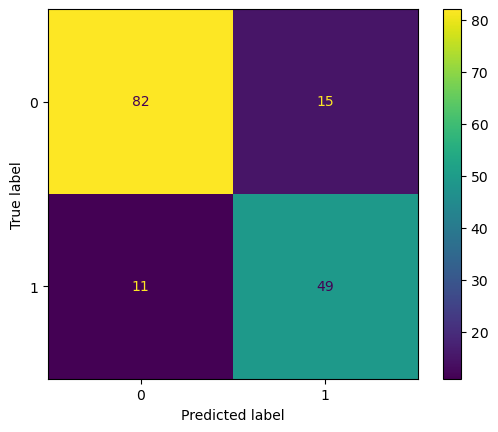

In [495]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()